# Statistical TDA

**Doing inference with persistence diagrams — from stability guarantees to hypothesis testing**

*Part of the [Topology & TDA](https://www.formalml.com/paths#topology) track on [formalML](https://www.formalml.com)*

---

## Overview & Motivation

The previous topics in this track gave us the machinery to compute topological summaries of data: we built **simplicial complexes** from point clouds, computed **persistent homology** to track features across scales, measured distances between persistence diagrams via the **bottleneck distance**, and used the **Mapper algorithm** to produce interpretable graph summaries of high-dimensional datasets.

But a fundamental question remains: **how do we know which topological features are real?**

Persistent homology applied to a finite sample $X_n = \{x_1, \ldots, x_n\} \subset \mathbb{R}^d$ produces a persistence diagram $\text{Dgm}(X_n)$. This diagram is a *random object* — draw a different sample from the same distribution, and you get a different diagram. Some bars in the barcode are genuine topological features of the underlying space; others are sampling noise. **Statistical TDA** gives us the tools to tell them apart.

This topic covers four pillars:

1. **Stability & Convergence** — the theoretical foundation: persistence diagrams are stable under perturbations, and empirical diagrams converge to the true diagram as $n \to \infty$.
2. **Confidence Sets via Bootstrap** — constructing confidence bands around persistence diagrams to determine which features are statistically significant.
3. **Vectorization for ML** — mapping persistence diagrams into Banach and Hilbert spaces (persistence landscapes, persistence images) where standard statistical tools apply.
4. **Hypothesis Testing** — permutation tests and two-sample tests on topological summaries.

### Prerequisites

- [Simplicial Complexes](https://www.formalml.com/topics/simplicial-complexes)
- [Barcodes & Bottleneck Distance](https://www.formalml.com/topics/barcodes-bottleneck)
- [Persistent Homology](https://www.formalml.com/topics/persistent-homology)

### Key References

| Reference | Role |
|-----------|------|
| Chazal, de Silva, Glisse, Oudot (2016). *The Structure and Stability of Persistence Modules*. Springer. | Stability theory |
| Fasy, Lecci, Rinaldo, Wasserman, et al. (2014). "Confidence sets for persistence diagrams." *Annals of Statistics*, 42(6). | Bootstrap confidence sets |
| Bubenik (2015). "Statistical topological data analysis using persistence landscapes." *JMLR*, 16(1). | Persistence landscapes |
| Adams, Emerson, Kirby, Neville, Peterson, Shipman, et al. (2017). "Persistence images: a stable vector representation." *JMLR*, 18(1). | Persistence images |
| Chazal & Michel (2021). "An Introduction to Topological Data Analysis." *Frontiers in AI*, 4. | Survey / context |

---

## Setup

We use `ripser` for persistent homology computation, `persim` for persistence diagram utilities, and `scikit-tda` ecosystem tools. For persistence landscapes we implement from scratch (and compare with library implementations).

In [1]:
# Core dependencies
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.spatial.distance import pdist, squareform
from scipy.stats import norm, gaussian_kde
from sklearn.decomposition import PCA

# TDA libraries
from ripser import ripser
from persim import plot_diagrams, bottleneck, wasserstein

# Reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'lines.linewidth': 2,
    'figure.dpi': 100,
})

print("All imports successful")

All imports successful


---

## 1. Stability & Convergence

### The Stability Theorem

The **Stability Theorem** is the theoretical bedrock of statistical TDA. It says that small perturbations of the input data produce small changes in the persistence diagram — making persistence a *robust* summary.

**Theorem 1 (Stability, Cohen-Steiner, Edelsbrunner, Harer, 2007).**
Let $f, g: X \to \mathbb{R}$ be tame functions on a topological space $X$. Then:

$$d_B(\text{Dgm}(f), \text{Dgm}(g)) \leq \|f - g\|_\infty$$

where $d_B$ is the bottleneck distance between persistence diagrams.

For Vietoris-Rips filtrations built from point clouds, this translates to:

**Corollary.** Let $X, Y \subset \mathbb{R}^d$ be finite point clouds. Then:

$$d_B(\text{Dgm}(\text{VR}(X)), \text{Dgm}(\text{VR}(Y))) \leq 2 \, d_H(X, Y)$$

where $d_H$ is the Hausdorff distance.

This means: if two point clouds are close in Hausdorff distance, their persistence diagrams are close in bottleneck distance. The topological summary is **Lipschitz-continuous** with respect to the input.

### Why Stability Matters for Statistics

Stability is what makes TDA *amenable to statistical reasoning*. Without it, we could not:

- Talk about convergence of empirical diagrams to a population diagram
- Construct confidence intervals
- Perform hypothesis tests

It tells us that persistence diagrams live in a well-behaved metric space, not some wild combinatorial object that could change arbitrarily under small perturbations.

### Demonstration: Stability Under Perturbation

We sample from a circle, then add increasing amounts of Gaussian noise to show that the bottleneck distance between the original and perturbed diagrams grows proportionally to the perturbation magnitude.

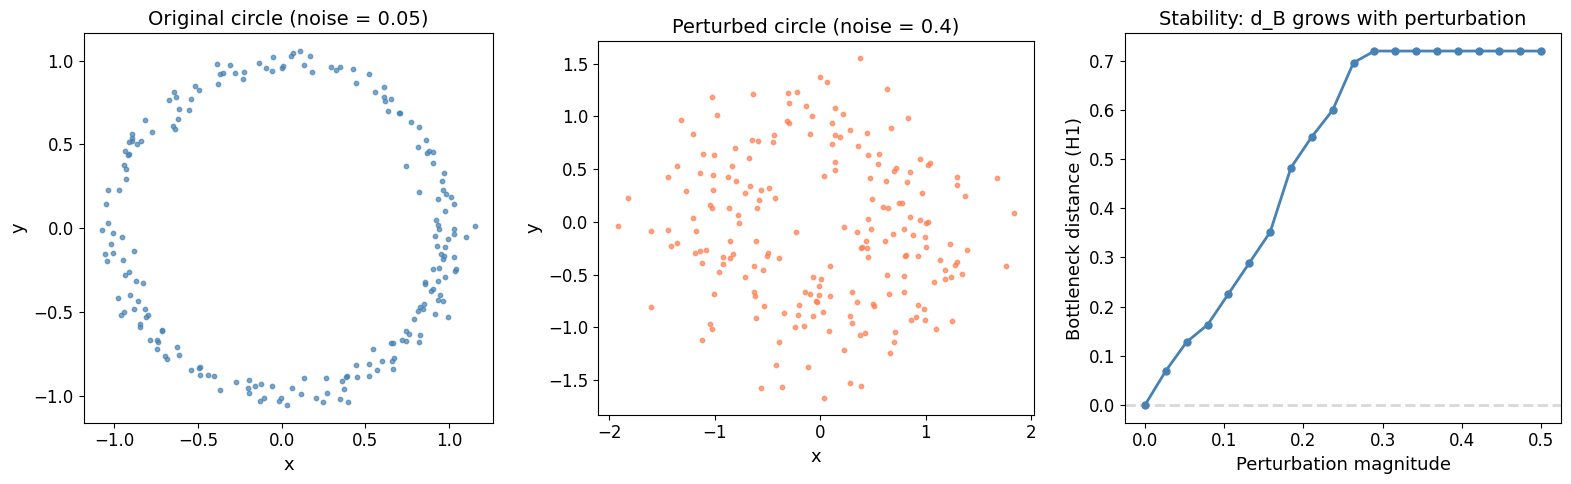

Max perturbation = 0.50, bottleneck dist = 0.7197


In [2]:
def sample_circle(n, noise=0.0, seed=None):
    """Sample n points from a unit circle with optional Gaussian noise."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    X = np.column_stack([np.cos(theta), np.sin(theta)])
    if noise > 0:
        X += rng.normal(0, noise, X.shape)
    return X

# Base sample
X_base = sample_circle(200, noise=0.05, seed=0)
dgm_base = ripser(X_base, maxdim=1)['dgms']

# Increasing perturbation levels
noise_levels = np.linspace(0.0, 0.5, 20)
bottleneck_dists = []

for sigma in noise_levels:
    X_pert = X_base + np.random.default_rng(1).normal(0, sigma, X_base.shape)
    dgm_pert = ripser(X_pert, maxdim=1)['dgms']
    d = bottleneck(dgm_base[1], dgm_pert[1])
    bottleneck_dists.append(d)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: original point cloud
axes[0].scatter(X_base[:, 0], X_base[:, 1], s=10, alpha=0.7, c='steelblue')
axes[0].set_title('Original circle (noise = 0.05)')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Middle: heavily perturbed
X_heavy = X_base + np.random.default_rng(1).normal(0, 0.4, X_base.shape)
axes[1].scatter(X_heavy[:, 0], X_heavy[:, 1], s=10, alpha=0.7, c='coral')
axes[1].set_title('Perturbed circle (noise = 0.4)')
axes[1].set_aspect('equal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Right: bottleneck distance vs perturbation
axes[2].plot(noise_levels, bottleneck_dists, 'o-', color='steelblue', markersize=5)
axes[2].set_xlabel('Perturbation magnitude')
axes[2].set_ylabel('Bottleneck distance (H1)')
axes[2].set_title('Stability: d_B grows with perturbation')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('stability_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Max perturbation = {noise_levels[-1]:.2f}, bottleneck dist = {bottleneck_dists[-1]:.4f}")

### Convergence of Empirical Persistence Diagrams

The Stability Theorem gives us a deterministic bound. To do *statistics*, we need a probabilistic statement: as the sample size $n \to \infty$, the empirical persistence diagram $\text{Dgm}(X_n)$ converges to the true diagram $\text{Dgm}(\mu)$ of the underlying distribution.

**Theorem 2 (Convergence Rate, Chazal & Oudot, 2008; Chazal et al., 2015).**
Let $\mu$ be a probability measure on a compact subset of $\mathbb{R}^d$, and let $X_n$ be an i.i.d. sample of size $n$ from $\mu$. Then:

$$d_B(\text{Dgm}(X_n), \text{Dgm}(\mu)) = O\left(\left(\frac{\log n}{n}\right)^{1/d}\right)$$

with high probability. The rate depends on the ambient dimension $d$ — the **curse of dimensionality** appears even in topological inference.

This convergence result is what justifies treating persistence diagrams as statistical estimators. The empirical diagram is a *consistent estimator* of the population diagram, and the convergence rate tells us how many samples we need for a given accuracy.

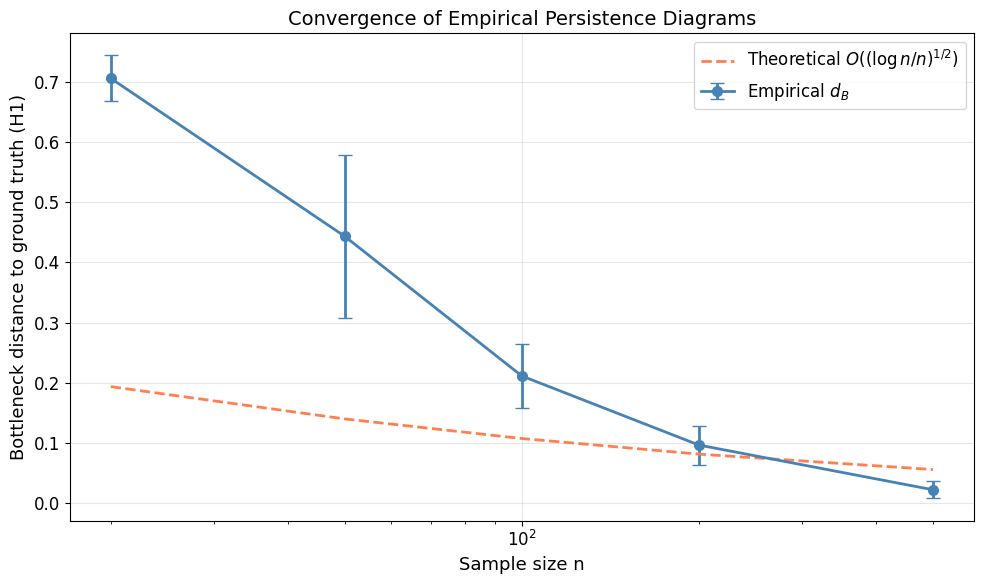

In [3]:
import warnings

def filter_diagram(dgm):
    """Remove infinite-death points."""
    return dgm[np.isfinite(dgm[:, 1])]

sample_sizes = [20, 50, 100, 200, 500]
n_trials = 10

# 500 points is plenty — ripser runs in 0.3s instead of 100s
X_truth = sample_circle(500, noise=0.05, seed=99)
dgm_truth = ripser(X_truth, maxdim=1)['dgms']
dgm_truth_h1 = filter_diagram(dgm_truth[1])

convergence_means = []
convergence_stds = []

for n in sample_sizes:
    dists = []
    for trial in range(n_trials):
        X_n = sample_circle(n, noise=0.05, seed=trial * 100 + n)
        dgm_n = ripser(X_n, maxdim=1)['dgms']
        dgm_n_h1 = filter_diagram(dgm_n[1])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            d = bottleneck(dgm_truth_h1, dgm_n_h1)
        dists.append(d)
    convergence_means.append(np.mean(dists))
    convergence_stds.append(np.std(dists))

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(sample_sizes, convergence_means, yerr=convergence_stds,
            fmt='o-', color='steelblue', capsize=5, markersize=7, label='Empirical $d_B$')

# Theoretical rate: O((log n / n)^{1/d}) with d=2
log_n = np.log(np.array(sample_sizes, dtype=float))
theoretical = 0.5 * (log_n / np.array(sample_sizes, dtype=float)) ** 0.5
ax.plot(sample_sizes, theoretical, '--', color='coral', linewidth=2,
        label=r'Theoretical $O((\log n / n)^{1/2})$')

ax.set_xlabel('Sample size n')
ax.set_ylabel('Bottleneck distance to ground truth (H1)')
ax.set_title('Convergence of Empirical Persistence Diagrams')
ax.set_xscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_demo.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 2. Confidence Sets for Persistence Diagrams

### The Problem

Given a persistence diagram $\text{Dgm}(X_n)$ from a finite sample, which features are **statistically significant** and which are **noise**?

A bar $(b, d)$ in the barcode with a large persistence $d - b$ is intuitively "more real" than a short bar. But how large is large enough? We need a formal threshold — a **confidence set** that separates signal from noise.

### The Bootstrap Approach (Fasy et al., 2014)

The key idea from Fasy, Lecci, Rinaldo, Wasserman, et al. (2014) is elegant:

1. Draw $B$ bootstrap samples $X_n^{*(1)}, \ldots, X_n^{*(B)}$ from $X_n$ (sampling with replacement).
2. Compute the persistence diagram for each: $\text{Dgm}(X_n^{*(b)})$.
3. Compute the bottleneck distance between each bootstrap diagram and the original: $\delta_b = d_B(\text{Dgm}(X_n), \text{Dgm}(X_n^{*(b)}))$.
4. The $\alpha$-confidence threshold is $c_\alpha = \text{quantile}_{1-\alpha}(\delta_1, \ldots, \delta_B)$.

**Interpretation:** Any bar in the barcode with persistence $> 2 c_\alpha$ is statistically significant at level $\alpha$. Points within distance $c_\alpha$ of the diagonal in the persistence diagram are **not distinguishable from noise** at the given confidence level.

The **confidence band** is the strip of width $c_\alpha$ above the diagonal:

$$\mathcal{B}_\alpha = \{(b, d) : d - b \leq 2 c_\alpha\}$$

Points outside this band are significant features; points inside are noise.

In [4]:
import warnings

def filter_diagram(dgm):
    """Remove infinite-death points."""
    return dgm[np.isfinite(dgm[:, 1])]

sample_sizes = [20, 50, 100, 200, 500]
n_trials = 10

# 500 points is plenty — ripser runs in 0.3s instead of 100s
X_truth = sample_circle(500, noise=0.05, seed=99)
dgm_truth = ripser(X_truth, maxdim=1)['dgms']
dgm_truth_h1 = filter_diagram(dgm_truth[1])

convergence_means = []
convergence_stds = []

for n in sample_sizes:
    dists = []
    for trial in range(n_trials):
        X_n = sample_circle(n, noise=0.05, seed=trial * 100 + n)
        dgm_n = ripser(X_n, maxdim=1)['dgms']
        dgm_n_h1 = filter_diagram(dgm_n[1])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            d = bottleneck(dgm_truth_h1, dgm_n_h1)
        dists.append(d)
    convergence_means.append(np.mean(dists))
    convergence_stds.append(np.std(dists))


### Example: Circle with Noise

We apply the bootstrap to a noisy circle sample. The H1 diagram should show one significant point (the loop) well above the confidence band, with everything else falling inside the band (noise).

In [8]:
def bootstrap_confidence_band(X, maxdim=1, n_bootstrap=100, alpha=0.05, seed=None):
    """
    Compute a bootstrap confidence band for a persistence diagram.
    
    Following Fasy, Lecci, Rinaldo, Wasserman et al. (2014):
    1. Compute the persistence diagram of the original data.
    2. Draw B bootstrap samples (with replacement) and compute their diagrams.
    3. Compute bottleneck distances between each bootstrap diagram and the original.
    4. The confidence threshold c_alpha is the (1-alpha) quantile of those distances.
    
    Parameters
    ----------
    X : ndarray of shape (n, d)
        Input point cloud.
    maxdim : int
        Maximum homology dimension to compute.
    n_bootstrap : int
        Number of bootstrap resamples.
    alpha : float
        Significance level (e.g., 0.05 for 95% confidence).
    seed : int or None
        Random seed for reproducibility.
    
    Returns
    -------
    dgms : list of ndarrays
        Persistence diagrams of the original data.
    c_alpha : float
        The (1-alpha) quantile of bootstrap bottleneck distances.
    boot_dists : ndarray
        Array of bottleneck distances from each bootstrap resample.
    """
    import warnings
    
    rng = np.random.default_rng(seed)
    n = len(X)
    
    # Compute persistence diagram of the original data
    result = ripser(X, maxdim=maxdim)
    dgms = result['dgms']
    
    # Filter the H1 diagram (remove infinite-death points) for distance computation
    dgm_h1_orig = dgms[maxdim]
    dgm_h1_orig_finite = dgm_h1_orig[np.isfinite(dgm_h1_orig[:, 1])]
    
    boot_dists = np.zeros(n_bootstrap)
    
    for b in range(n_bootstrap):
        # Bootstrap resample (with replacement)
        indices = rng.choice(n, size=n, replace=True)
        X_boot = X[indices]
        
        # Compute persistence diagram of bootstrap sample
        dgm_boot = ripser(X_boot, maxdim=maxdim)['dgms']
        dgm_boot_h1 = dgm_boot[maxdim]
        dgm_boot_h1_finite = dgm_boot_h1[np.isfinite(dgm_boot_h1[:, 1])]
        
        # Bottleneck distance between original and bootstrap diagram
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            boot_dists[b] = bottleneck(dgm_h1_orig_finite, dgm_boot_h1_finite)
    
    # Confidence threshold: (1-alpha) quantile
    c_alpha = np.quantile(boot_dists, 1 - alpha)
    
    return dgms, c_alpha, boot_dists


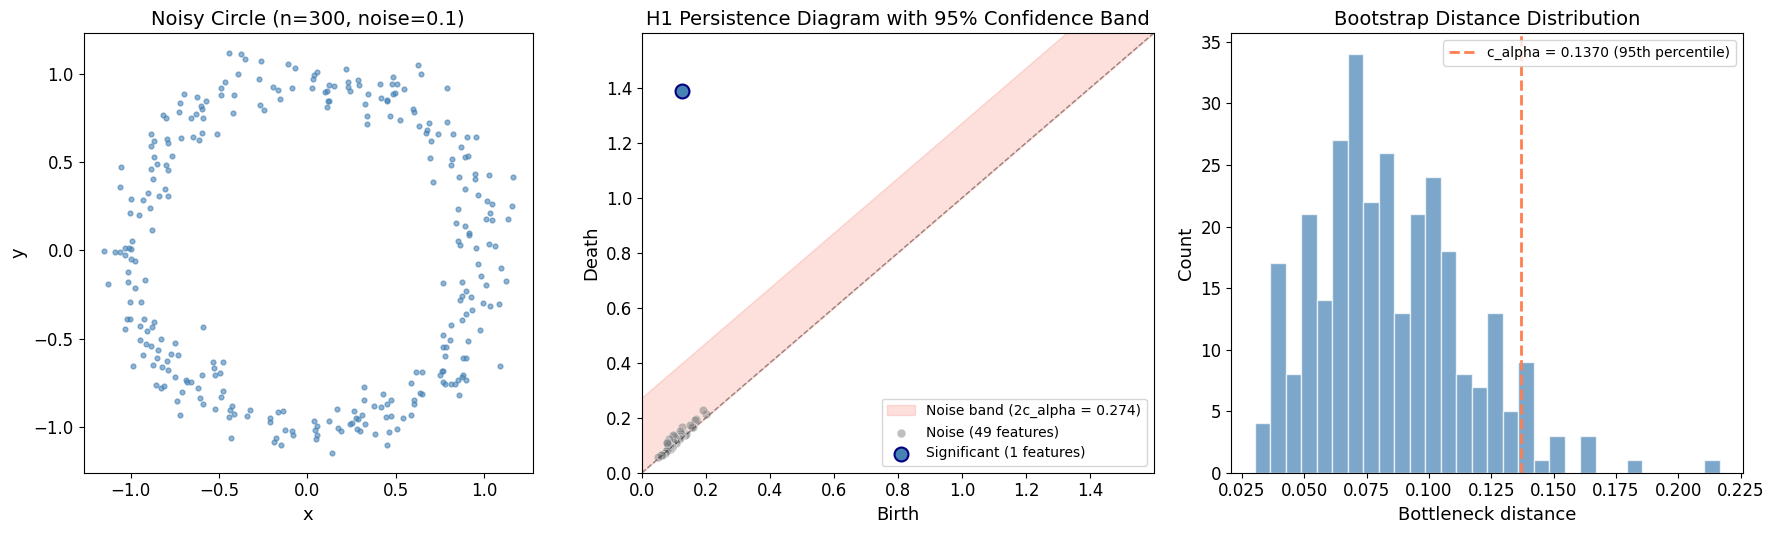


95% confidence threshold c_alpha = 0.1370
Significance threshold 2*c_alpha = 0.2739
Significant H1 features: 1
Noise H1 features: 49
  Feature 1: birth=0.1262, death=1.3902, persistence=1.2640


In [9]:
# Generate noisy circle
X_circle = sample_circle(300, noise=0.1, seed=7)

# Compute bootstrap confidence band
dgms, c_alpha, boot_dists = bootstrap_confidence_band(
    X_circle, maxdim=1, n_bootstrap=300, alpha=0.05, seed=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Left: point cloud
axes[0].scatter(X_circle[:, 0], X_circle[:, 1], s=12, alpha=0.6, c='steelblue')
axes[0].set_title('Noisy Circle (n=300, noise=0.1)')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Middle: H1 persistence diagram with confidence band
dgm_h1 = dgms[1]
ax = axes[1]

# Plot diagonal
diag_min = 0
diag_max = max(dgm_h1[:, 1].max(), 1.0) * 1.15
ax.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.4, linewidth=1)

# Confidence band (shaded region above diagonal)
x_fill = np.linspace(diag_min, diag_max, 100)
ax.fill_between(x_fill, x_fill, x_fill + 2 * c_alpha,
                color='salmon', alpha=0.25, label=f'Noise band (2c_alpha = {2*c_alpha:.3f})')

# Plot persistence points
significant = dgm_h1[:, 1] - dgm_h1[:, 0] > 2 * c_alpha
noise = ~significant

ax.scatter(dgm_h1[noise, 0], dgm_h1[noise, 1],
           s=40, c='gray', alpha=0.5, edgecolors='white', linewidths=0.5,
           label=f'Noise ({noise.sum()} features)')
ax.scatter(dgm_h1[significant, 0], dgm_h1[significant, 1],
           s=100, c='steelblue', edgecolors='navy', linewidths=1.5, zorder=5,
           label=f'Significant ({significant.sum()} features)')

ax.set_xlabel('Birth')
ax.set_ylabel('Death')
ax.set_title('H1 Persistence Diagram with 95% Confidence Band')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(diag_min, diag_max)
ax.set_ylim(diag_min, diag_max)

# Right: bootstrap distance distribution
axes[2].hist(boot_dists, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[2].axvline(c_alpha, color='coral', linewidth=2, linestyle='--',
                label=f'c_alpha = {c_alpha:.4f} (95th percentile)')
axes[2].set_xlabel('Bottleneck distance')
axes[2].set_ylabel('Count')
axes[2].set_title('Bootstrap Distance Distribution')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('bootstrap_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n95% confidence threshold c_alpha = {c_alpha:.4f}")
print(f"Significance threshold 2*c_alpha = {2*c_alpha:.4f}")
print(f"Significant H1 features: {significant.sum()}")
print(f"Noise H1 features: {noise.sum()}")
for i, (b, d) in enumerate(dgm_h1[significant]):
    print(f"  Feature {i+1}: birth={b:.4f}, death={d:.4f}, persistence={d-b:.4f}")

---

## 3. Vectorization: Persistence Landscapes & Images

### The Problem with Diagram Space

Persistence diagrams live in a metric space equipped with the bottleneck and Wasserstein distances, but this space is **not a vector space**. You cannot:

- Compute a *mean* persistence diagram (the Frechet mean exists but is NP-hard to compute exactly)
- Apply linear methods (PCA, regression, kernel SVMs with standard kernels)
- Perform standard statistical tests that assume a Hilbert or Banach space structure

**Vectorization** solves this by mapping persistence diagrams into function spaces where the full arsenal of statistics and machine learning applies.

### 3.1 Persistence Landscapes (Bubenik, 2015)

**Definition.** Given a persistence diagram $D = \{(b_i, d_i)\}$, define for each point the *tent function*:

$$\Lambda_i(t) = \max\left(0, \min\left(t - b_i, \; d_i - t\right)\right)$$

This is a piecewise-linear function that rises from 0 at $t = b_i$, peaks at $t = (b_i + d_i)/2$ with height $(d_i - b_i)/2$, and returns to 0 at $t = d_i$.

The **$k$-th persistence landscape** is the $k$-th largest value of the tent functions at each point:

$$\lambda_k(t) = k\text{-max}_{i} \; \Lambda_i(t)$$

where $k\text{-max}$ denotes the $k$-th largest value.

**Key properties:**
- Persistence landscapes are elements of a **Banach space** $L^p(\mathbb{R})$
- They satisfy a **strong law of large numbers**: the sample mean landscape converges to the population mean landscape
- They satisfy a **central limit theorem**: $\sqrt{n}(\bar{\lambda}_n - \lambda) \xrightarrow{d} \mathcal{N}(0, \Sigma)$
- They are **stable**: $\|\lambda_D - \lambda_{D'}\|_\infty \leq d_B(D, D')$

These properties mean we can compute means, variances, and confidence intervals on persistence landscapes using standard statistical tools — something impossible directly on persistence diagrams.

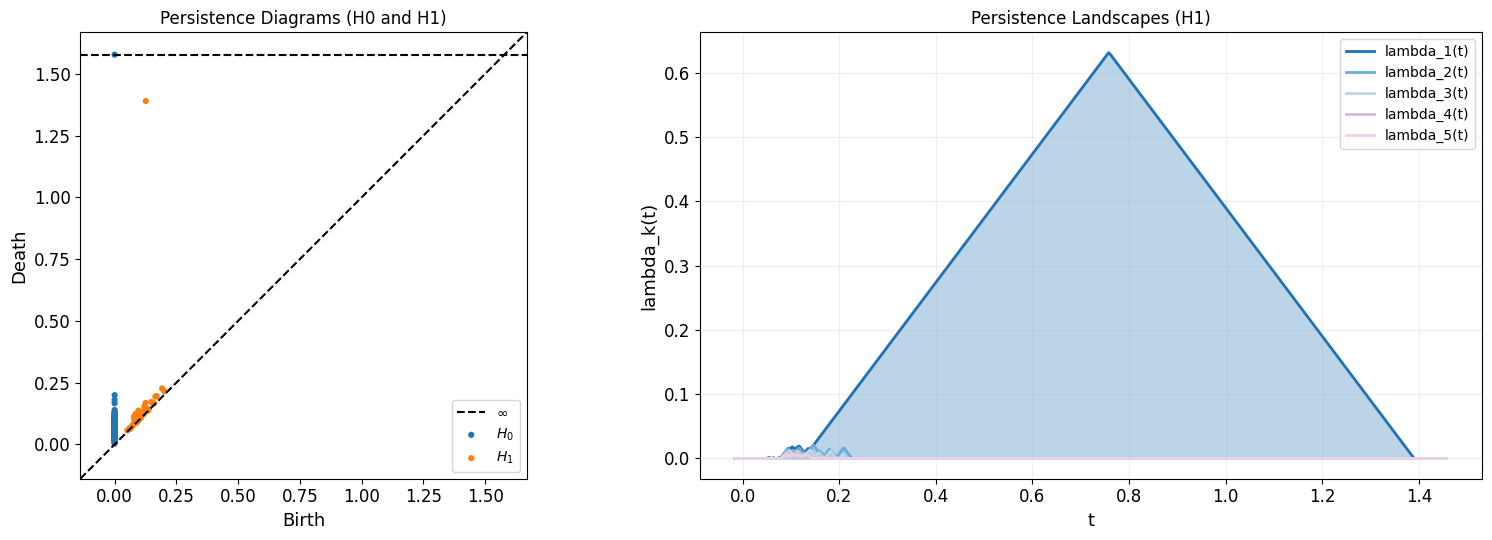

Number of H1 features: 50
Max persistence: 1.2640
Peak of lambda_1: 0.6316


In [10]:
def persistence_landscape(dgm, k_max=5, t_min=None, t_max=None, n_points=500):
    """
    Compute persistence landscapes from a persistence diagram.
    
    Parameters
    ----------
    dgm : ndarray of shape (m, 2)
        Persistence diagram with columns (birth, death).
    k_max : int
        Number of landscape layers to compute.
    t_min, t_max : float or None
        Domain bounds; inferred from diagram if None.
    n_points : int
        Number of evaluation points.
    
    Returns
    -------
    t : ndarray of shape (n_points,)
        Evaluation grid.
    landscapes : ndarray of shape (k_max, n_points)
        Landscape functions lambda_1(t), ..., lambda_{k_max}(t).
    """
    # Remove infinite-death points
    finite_mask = np.isfinite(dgm[:, 1])
    dgm = dgm[finite_mask]
    
    if len(dgm) == 0:
        t = np.linspace(0, 1, n_points)
        return t, np.zeros((k_max, n_points))
    
    births = dgm[:, 0]
    deaths = dgm[:, 1]
    
    if t_min is None:
        t_min = births.min() - 0.05 * (deaths.max() - births.min())
    if t_max is None:
        t_max = deaths.max() + 0.05 * (deaths.max() - births.min())
    
    t = np.linspace(t_min, t_max, n_points)
    
    # Compute tent functions for each persistence pair
    # Lambda_i(t) = max(0, min(t - b_i, d_i - t))
    tent_values = np.zeros((len(dgm), n_points))
    for i, (b, d) in enumerate(dgm):
        tent_values[i] = np.maximum(0, np.minimum(t - b, d - t))
    
    # k-th landscape = k-th largest tent value at each t
    sorted_tents = np.sort(tent_values, axis=0)[::-1]
    
    landscapes = np.zeros((k_max, n_points))
    for k in range(min(k_max, len(dgm))):
        landscapes[k] = sorted_tents[k]
    
    return t, landscapes


# Demonstrate on the noisy circle
dgm_h1 = dgms[1]
t, landscapes = persistence_landscape(dgm_h1, k_max=5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: persistence diagram for reference
ax = axes[0]
plot_diagrams(dgms, ax=ax, show=False)
ax.set_title('Persistence Diagrams (H0 and H1)')

# Right: persistence landscapes
ax = axes[1]
colors = ['#2171b5', '#6baed6', '#bdd7e7', '#d4b9da', '#e7d4e8']
for k in range(5):
    if np.max(landscapes[k]) > 1e-10:
        ax.fill_between(t, 0, landscapes[k], alpha=0.3, color=colors[k])
        ax.plot(t, landscapes[k], color=colors[k], linewidth=2,
                label=f'lambda_{k+1}(t)')

ax.set_xlabel('t')
ax.set_ylabel('lambda_k(t)')
ax.set_title('Persistence Landscapes (H1)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('persistence_landscapes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of H1 features: {len(dgm_h1)}")
print(f"Max persistence: {(dgm_h1[:,1] - dgm_h1[:,0]).max():.4f}")
print(f"Peak of lambda_1: {landscapes[0].max():.4f}")

### 3.2 Persistence Images (Adams et al., 2017)

While persistence landscapes map diagrams to function spaces, **persistence images** map them to finite-dimensional vectors — specifically, to pixel grids that can be fed directly to any machine learning model.

**Construction:**

1. **Rotate** the persistence diagram: transform each point $(b, d)$ to $(b, d-b)$ — the birth-persistence plane. This makes the diagonal become the horizontal axis.

2. **Weight**: Apply a weighting function $w(b, p)$ that assigns higher weight to points with larger persistence $p = d - b$. A common choice is $w(b, p) = p$ (linear ramp) or a sigmoid.

3. **Smooth**: Place a 2D Gaussian $\mathcal{N}((b_i, p_i), \sigma^2 I)$ at each weighted point.

4. **Discretize**: Evaluate the smoothed surface on a pixel grid to produce a vector $\mathbf{v} \in \mathbb{R}^{N \times N}$.

**Key property:** Persistence images are **stable** — $\|\text{PI}(D) - \text{PI}(D')\|_2 \leq C \cdot d_W^1(D, D')$ where $d_W^1$ is the 1-Wasserstein distance.

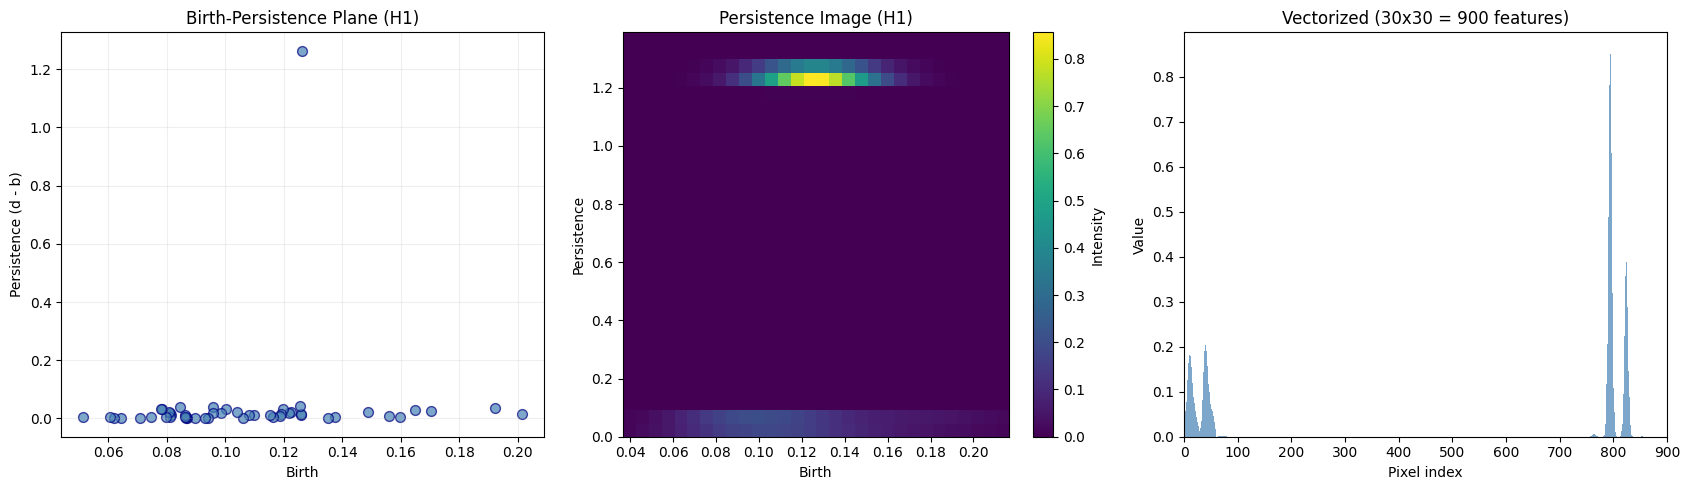

Persistence image shape: (30, 30)
Feature vector dimension: 900
Max intensity: 0.8562


In [11]:
def persistence_image(dgm, pixel_size=20, sigma=None, weight_fn=None,
                      birth_range=None, pers_range=None):
    """
    Compute a persistence image from a persistence diagram.
    
    Parameters
    ----------
    dgm : ndarray of shape (m, 2)
        Persistence diagram (birth, death).
    pixel_size : int
        Resolution of the image grid.
    sigma : float or None
        Bandwidth of Gaussian kernel; auto-computed if None.
    weight_fn : callable or None
        Weight function w(birth, persistence); default is linear ramp.
    birth_range, pers_range : tuple or None
        Ranges for the grid; inferred if None.
    
    Returns
    -------
    img : ndarray of shape (pixel_size, pixel_size)
        The persistence image.
    birth_grid : ndarray
        Birth axis values.
    pers_grid : ndarray
        Persistence axis values.
    """
    # Remove infinite points
    finite_mask = np.isfinite(dgm[:, 1])
    dgm = dgm[finite_mask]
    
    if len(dgm) == 0:
        return np.zeros((pixel_size, pixel_size)), None, None
    
    # Transform to birth-persistence coordinates
    births = dgm[:, 0]
    pers = dgm[:, 1] - dgm[:, 0]
    
    # Filter out zero-persistence points
    nonzero = pers > 1e-10
    births = births[nonzero]
    pers = pers[nonzero]
    
    if len(births) == 0:
        return np.zeros((pixel_size, pixel_size)), None, None
    
    # Set ranges
    if birth_range is None:
        bmin, bmax = births.min(), births.max()
        bpad = 0.1 * (bmax - bmin) if bmax > bmin else 0.1
        birth_range = (bmin - bpad, bmax + bpad)
    if pers_range is None:
        pmin, pmax = 0, pers.max()
        ppad = 0.1 * pmax if pmax > 0 else 0.1
        pers_range = (pmin, pmax + ppad)
    
    # Auto sigma
    if sigma is None:
        sigma = max(
            (birth_range[1] - birth_range[0]) / pixel_size,
            (pers_range[1] - pers_range[0]) / pixel_size
        )
    
    # Default weight: linear ramp on persistence
    if weight_fn is None:
        weight_fn = lambda b, p: p
    
    # Build grid
    birth_grid = np.linspace(birth_range[0], birth_range[1], pixel_size)
    pers_grid = np.linspace(pers_range[0], pers_range[1], pixel_size)
    B, P = np.meshgrid(birth_grid, pers_grid)
    
    # Accumulate weighted Gaussians
    img = np.zeros_like(B)
    for bi, pi in zip(births, pers):
        w = weight_fn(bi, pi)
        gauss = np.exp(-((B - bi)**2 + (P - pi)**2) / (2 * sigma**2))
        img += w * gauss
    
    return img, birth_grid, pers_grid


# Compute persistence image for the circle
pixel_size = 30
img, b_grid, p_grid = persistence_image(dgm_h1, pixel_size=pixel_size, sigma=0.02)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: birth-persistence diagram
ax = axes[0]
finite = np.isfinite(dgm_h1[:, 1])
b = dgm_h1[finite, 0]
p = dgm_h1[finite, 1] - dgm_h1[finite, 0]
ax.scatter(b, p, s=50, c='steelblue', edgecolors='navy', alpha=0.7)
ax.set_xlabel('Birth')
ax.set_ylabel('Persistence (d - b)')
ax.set_title('Birth-Persistence Plane (H1)')
ax.grid(True, alpha=0.2)

# Middle: persistence image
ax = axes[1]
im = ax.imshow(img, origin='lower', cmap='viridis', aspect='auto',
               extent=[b_grid[0], b_grid[-1], p_grid[0], p_grid[-1]])
ax.set_xlabel('Birth')
ax.set_ylabel('Persistence')
ax.set_title('Persistence Image (H1)')
plt.colorbar(im, ax=ax, label='Intensity')

# Right: flattened vector
ax = axes[2]
ax.bar(range(len(img.ravel())), img.ravel(), width=1, color='steelblue', alpha=0.7)
ax.set_xlabel('Pixel index')
ax.set_ylabel('Value')
ax.set_title(f'Vectorized ({pixel_size}x{pixel_size} = {pixel_size**2} features)')
ax.set_xlim(0, len(img.ravel()))

plt.tight_layout()
plt.savefig('persistence_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Persistence image shape: {img.shape}")
print(f"Feature vector dimension: {img.ravel().shape[0]}")
print(f"Max intensity: {img.max():.4f}")

---

## 4. Hypothesis Testing with Persistence Landscapes

### The Central Limit Theorem for Landscapes

Because persistence landscapes live in a Banach space and satisfy a CLT (Bubenik, 2015), we can perform **permutation tests** comparing the topological summaries of two datasets.

**Two-Sample Test:**

Given two point clouds $X = \{x_1, \ldots, x_m\}$ and $Y = \{y_1, \ldots, y_n\}$, we want to test:

$$H_0: \lambda_X = \lambda_Y \quad \text{(same underlying topology)}$$
$$H_1: \lambda_X \neq \lambda_Y \quad \text{(different topology)}$$

**Procedure:**

1. Compute the mean persistence landscape $\bar{\lambda}_X$ and $\bar{\lambda}_Y$ from bootstrap resamples of each dataset.
2. Define the test statistic: $T = \|\bar{\lambda}_X - \bar{\lambda}_Y\|_2$
3. Under $H_0$, permute the labels: pool $X \cup Y$, randomly split into two groups of size $m$ and $n$, recompute $T$.
4. Repeat $B$ times to build the null distribution of $T$.
5. Compute the $p$-value: $p = \frac{1}{B} \sum_{b=1}^B \mathbf{1}[T_b \geq T_\text{obs}]$

### Application: Do Two Shapes Have Different Topology?

We test whether a circle and a figure-eight have statistically different $H_1$ topology (they should — the circle has $\beta_1 = 1$ and the figure-eight has $\beta_1 = 2$).

Running permutation test: Circle vs Figure-Eight
(This may take a minute...)

  Permutation 50/200...
  Permutation 100/200...
  Permutation 150/200...
  Permutation 200/200...


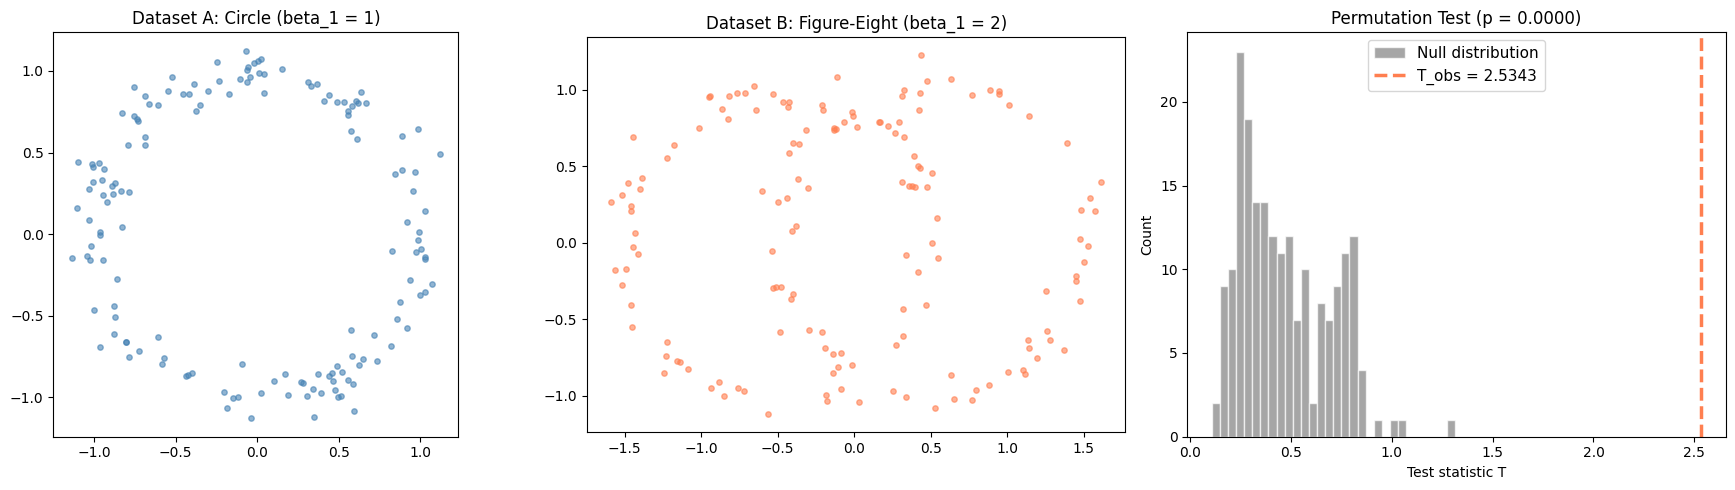


Test statistic T_obs = 2.5343
p-value = 0.0000
-> REJECT H0: The two shapes have statistically different topology (p < 0.05)


In [12]:
def sample_figure_eight(n, noise=0.05, seed=None):
    """Sample n points from a figure-eight (two tangent circles)."""
    rng = np.random.default_rng(seed)
    n1 = n // 2
    n2 = n - n1
    
    # Left circle centered at (-0.5, 0)
    theta1 = rng.uniform(0, 2 * np.pi, n1)
    X1 = np.column_stack([np.cos(theta1) - 0.5, np.sin(theta1)])
    
    # Right circle centered at (0.5, 0), tangent at origin
    theta2 = rng.uniform(0, 2 * np.pi, n2)
    X2 = np.column_stack([np.cos(theta2) + 0.5, np.sin(theta2)])
    
    X = np.vstack([X1, X2])
    X += rng.normal(0, noise, X.shape)
    return X


def landscape_permutation_test(X, Y, maxdim=1, k_max=3, n_perm=500,
                                n_bootstrap=30, seed=42):
    """
    Permutation test on persistence landscapes.
    Tests H0: same topology vs H1: different topology.
    
    Returns: p_value, T_obs, T_null
    """
    rng = np.random.default_rng(seed)
    m, n = len(X), len(Y)
    
    def mean_landscape_from_bootstraps(data, n_boot, rng_local):
        all_landscapes = []
        for _ in range(n_boot):
            idx = rng_local.choice(len(data), size=len(data), replace=True)
            dgm = ripser(data[idx], maxdim=maxdim)['dgms'][maxdim]
            t, L = persistence_landscape(dgm, k_max=k_max, n_points=200)
            all_landscapes.append(L.ravel())
        return np.mean(all_landscapes, axis=0)
    
    def test_statistic(data_a, data_b, rng_local):
        L_a = mean_landscape_from_bootstraps(data_a, n_bootstrap, rng_local)
        L_b = mean_landscape_from_bootstraps(data_b, n_bootstrap, rng_local)
        return np.linalg.norm(L_a - L_b)
    
    # Observed test statistic
    T_obs = test_statistic(X, Y, rng)
    
    # Null distribution via permutation
    pooled = np.vstack([X, Y])
    T_null = np.zeros(n_perm)
    for p in range(n_perm):
        perm = rng.permutation(m + n)
        X_perm = pooled[perm[:m]]
        Y_perm = pooled[perm[m:]]
        T_null[p] = test_statistic(X_perm, Y_perm, rng)
        if (p + 1) % 50 == 0:
            print(f"  Permutation {p+1}/{n_perm}...")
    
    p_value = np.mean(T_null >= T_obs)
    return p_value, T_obs, T_null


# Generate two datasets with DIFFERENT topology
X_circ = sample_circle(150, noise=0.08, seed=10)       # beta_1 = 1
Y_fig8 = sample_figure_eight(150, noise=0.08, seed=20)  # beta_1 = 2

print("Running permutation test: Circle vs Figure-Eight")
print("(This may take a minute...)\n")
p_val, T_obs, T_null = landscape_permutation_test(
    X_circ, Y_fig8, maxdim=1, k_max=3, n_perm=200, n_bootstrap=15, seed=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: circle
axes[0].scatter(X_circ[:, 0], X_circ[:, 1], s=15, alpha=0.6, c='steelblue')
axes[0].set_title('Dataset A: Circle (beta_1 = 1)')
axes[0].set_aspect('equal')

# Middle: figure-eight
axes[1].scatter(Y_fig8[:, 0], Y_fig8[:, 1], s=15, alpha=0.6, c='coral')
axes[1].set_title('Dataset B: Figure-Eight (beta_1 = 2)')
axes[1].set_aspect('equal')

# Right: null distribution
axes[2].hist(T_null, bins=30, color='gray', alpha=0.7, edgecolor='white',
             label='Null distribution')
axes[2].axvline(T_obs, color='coral', linewidth=2.5, linestyle='--',
                label=f'T_obs = {T_obs:.4f}')
axes[2].set_xlabel('Test statistic T')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Permutation Test (p = {p_val:.4f})')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig('permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest statistic T_obs = {T_obs:.4f}")
print(f"p-value = {p_val:.4f}")
if p_val < 0.05:
    print("-> REJECT H0: The two shapes have statistically different topology (p < 0.05)")
else:
    print("-> FAIL TO REJECT H0")

### Sanity Check: Two Circles (Same Topology)

To verify the test isn't trivially rejecting everything, we test two samples from the *same* distribution — both circles with $\beta_1 = 1$. The test should **fail to reject** $H_0$.

Running permutation test: Circle vs Circle (same topology)
(This may take a minute...)

  Permutation 50/200...
  Permutation 100/200...
  Permutation 150/200...
  Permutation 200/200...


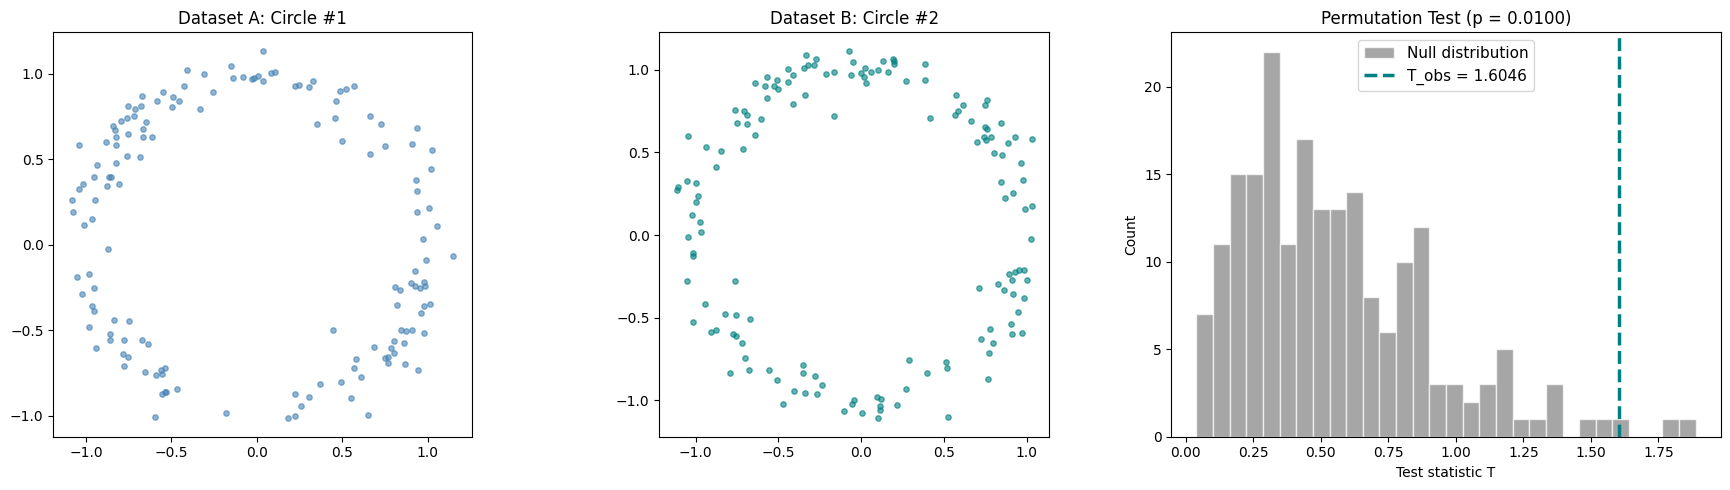


Test statistic T_obs = 1.6046
p-value = 0.0100
-> REJECT H0 (unexpected for same topology!)


In [13]:
# Two datasets with the SAME topology
X_circ1 = sample_circle(150, noise=0.08, seed=30)
X_circ2 = sample_circle(150, noise=0.08, seed=40)

print("Running permutation test: Circle vs Circle (same topology)")
print("(This may take a minute...)\n")
p_val_same, T_obs_same, T_null_same = landscape_permutation_test(
    X_circ1, X_circ2, maxdim=1, k_max=3, n_perm=200, n_bootstrap=15, seed=99
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_circ1[:, 0], X_circ1[:, 1], s=15, alpha=0.6, c='steelblue')
axes[0].set_title('Dataset A: Circle #1')
axes[0].set_aspect('equal')

axes[1].scatter(X_circ2[:, 0], X_circ2[:, 1], s=15, alpha=0.6, c='teal')
axes[1].set_title('Dataset B: Circle #2')
axes[1].set_aspect('equal')

axes[2].hist(T_null_same, bins=30, color='gray', alpha=0.7, edgecolor='white',
             label='Null distribution')
axes[2].axvline(T_obs_same, color='teal', linewidth=2.5, linestyle='--',
                label=f'T_obs = {T_obs_same:.4f}')
axes[2].set_xlabel('Test statistic T')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Permutation Test (p = {p_val_same:.4f})')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig('permutation_test_null.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest statistic T_obs = {T_obs_same:.4f}")
print(f"p-value = {p_val_same:.4f}")
if p_val_same < 0.05:
    print("-> REJECT H0 (unexpected for same topology!)")
else:
    print("-> FAIL TO REJECT H0: No evidence of different topology (as expected)")

---

## 5. Application: Topology of Financial Market Regimes

We tie statistical TDA back to a practical question relevant to quantitative finance:

> **Is the topology of equity return dynamics during market crises statistically different from calm periods?**

We simulate two market regimes — *calm* (low volatility, mean-reverting) and *crisis* (high volatility, heavy tails, correlated drawdowns) — embed rolling return windows as point clouds in a delay-embedding space, and apply our permutation test.

The hypothesis: crisis periods produce return trajectories that are topologically more complex (more loops, higher Betti numbers) due to feedback loops, herding, and volatility clustering.

Calm point cloud: (162, 75) (162 points in R^75)
Crisis point cloud: (162, 75) (162 points in R^75)


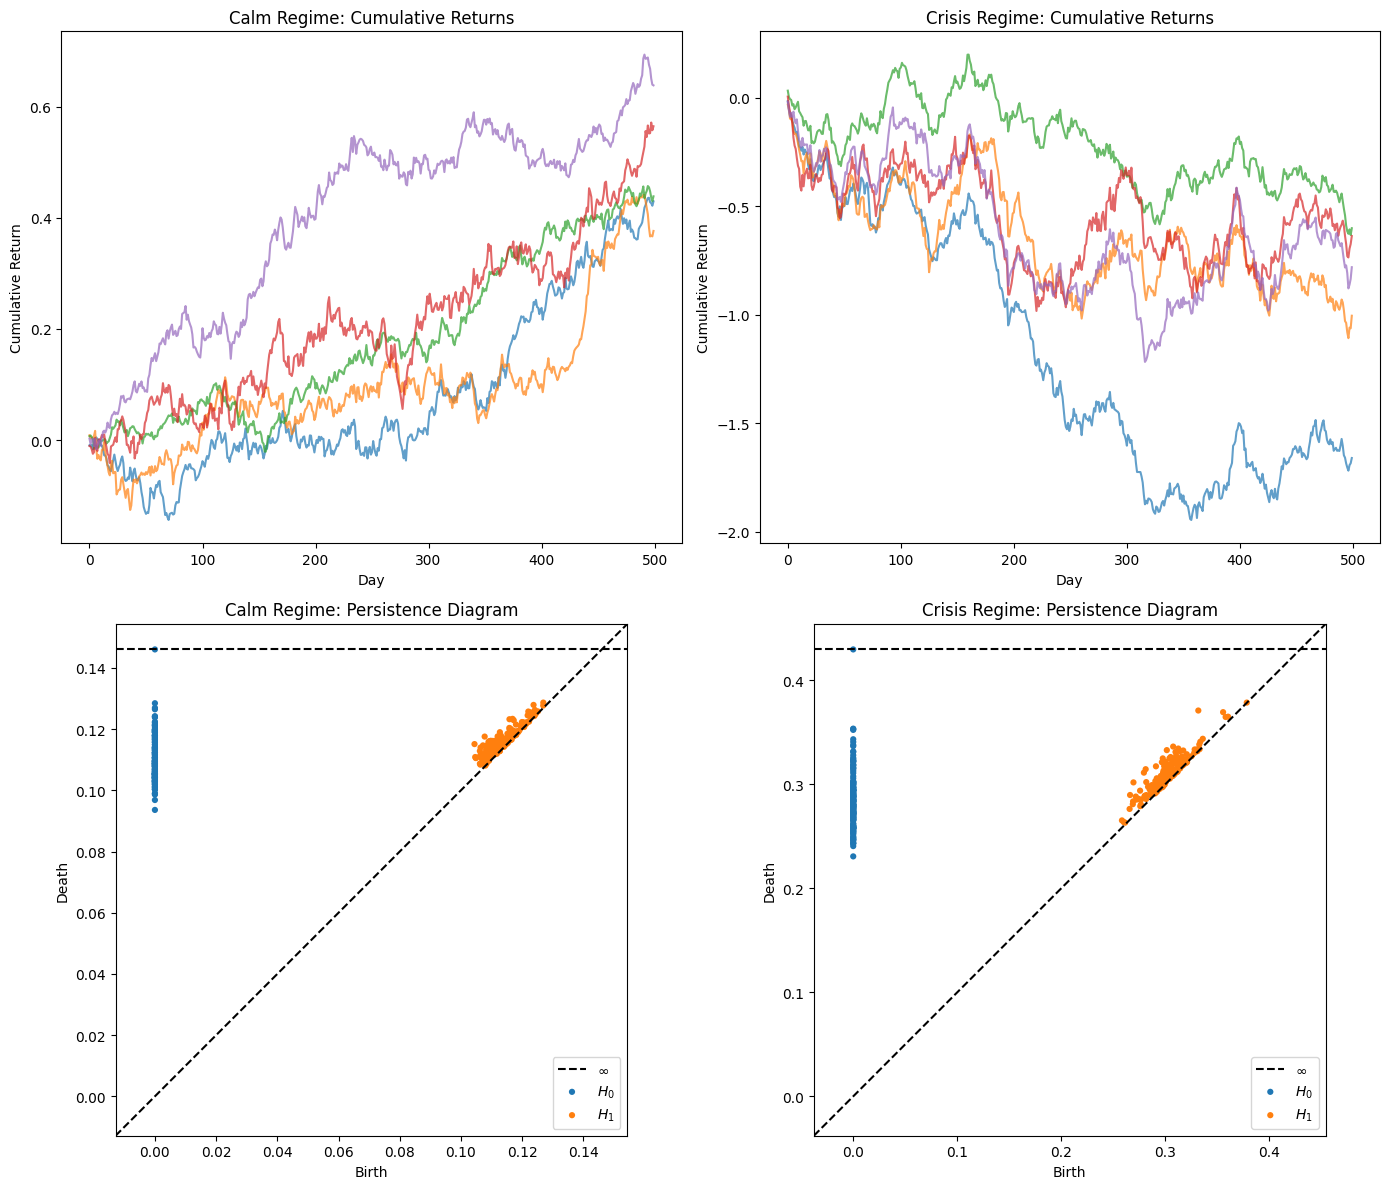


Calm regime:
  H0: 161 features, max persistence = 0.1285
  H1: 193 features, max persistence = 0.0107

Crisis regime:
  H0: 161 features, max persistence = 0.3536
  H1: 167 features, max persistence = 0.0392


In [14]:
def simulate_market_returns(n_days, regime='calm', seed=None):
    """
    Simulate daily returns for 5 correlated assets.
    
    Parameters
    ----------
    n_days : int
    regime : str, 'calm' or 'crisis'
    seed : int or None
    
    Returns
    -------
    returns : ndarray of shape (n_days, 5)
    """
    rng = np.random.default_rng(seed)
    
    if regime == 'calm':
        # Low vol, moderate correlation
        mu = np.array([0.0003, 0.0002, 0.0004, 0.0001, 0.0003])
        vol = np.array([0.01, 0.012, 0.008, 0.015, 0.011])
        corr = np.array([
            [1.0, 0.3, 0.2, 0.15, 0.25],
            [0.3, 1.0, 0.25, 0.2, 0.3],
            [0.2, 0.25, 1.0, 0.1, 0.15],
            [0.15, 0.2, 0.1, 1.0, 0.2],
            [0.25, 0.3, 0.15, 0.2, 1.0]
        ])
    else:
        # High vol, high correlation, fat tails
        mu = np.array([-0.001, -0.0015, -0.0008, -0.002, -0.0012])
        vol = np.array([0.03, 0.035, 0.025, 0.04, 0.032])
        corr = np.array([
            [1.0, 0.7, 0.65, 0.6, 0.72],
            [0.7, 1.0, 0.68, 0.75, 0.71],
            [0.65, 0.68, 1.0, 0.62, 0.66],
            [0.6, 0.75, 0.62, 1.0, 0.7],
            [0.72, 0.71, 0.66, 0.7, 1.0]
        ])
    
    cov = np.outer(vol, vol) * corr
    returns = rng.multivariate_normal(mu, cov, size=n_days)
    
    if regime == 'crisis':
        # Add occasional jumps (fat tails)
        jump_mask = rng.random(n_days) < 0.05
        returns[jump_mask] += rng.normal(-0.03, 0.02, (jump_mask.sum(), 5))
    
    return returns


def delay_embed(returns, window=20, step=5):
    """
    Create delay-embedded point cloud from rolling windows.
    Each point is a flattened window of (window x n_assets) returns.
    """
    n, d = returns.shape
    points = []
    for i in range(0, n - window, step):
        points.append(returns[i:i+window].ravel())
    return np.array(points)


# Simulate
calm_returns = simulate_market_returns(500, 'calm', seed=1)
crisis_returns = simulate_market_returns(500, 'crisis', seed=2)

# Delay-embed into point clouds
X_calm = delay_embed(calm_returns, window=15, step=3)
X_crisis = delay_embed(crisis_returns, window=15, step=3)

print(f"Calm point cloud: {X_calm.shape} ({X_calm.shape[0]} points in R^{X_calm.shape[1]})")
print(f"Crisis point cloud: {X_crisis.shape} ({X_crisis.shape[0]} points in R^{X_crisis.shape[1]})")

# Compute persistence for both
dgm_calm = ripser(X_calm, maxdim=1)['dgms']
dgm_crisis = ripser(X_crisis, maxdim=1)['dgms']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Cumulative returns
axes[0, 0].plot(np.cumsum(calm_returns, axis=0), alpha=0.7)
axes[0, 0].set_title('Calm Regime: Cumulative Returns')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Cumulative Return')

axes[0, 1].plot(np.cumsum(crisis_returns, axis=0), alpha=0.7)
axes[0, 1].set_title('Crisis Regime: Cumulative Returns')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Cumulative Return')

# Persistence diagrams
plot_diagrams(dgm_calm, ax=axes[1, 0], show=False)
axes[1, 0].set_title('Calm Regime: Persistence Diagram')

plot_diagrams(dgm_crisis, ax=axes[1, 1], show=False)
axes[1, 1].set_title('Crisis Regime: Persistence Diagram')

plt.tight_layout()
plt.savefig('financial_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick summary
for name, dgm in [('Calm', dgm_calm), ('Crisis', dgm_crisis)]:
    h0_pers = dgm[0][np.isfinite(dgm[0][:, 1]), 1] - dgm[0][np.isfinite(dgm[0][:, 1]), 0]
    h1_pers = dgm[1][:, 1] - dgm[1][:, 0] if len(dgm[1]) > 0 else np.array([0])
    print(f"\n{name} regime:")
    print(f"  H0: {len(h0_pers)} features, max persistence = {h0_pers.max():.4f}")
    print(f"  H1: {len(dgm[1])} features, max persistence = {h1_pers.max():.4f}")

Running permutation test: Calm vs Crisis regimes
(This will take a few minutes due to high dimensionality...)

  Permutation 50/150...
  Permutation 100/150...
  Permutation 150/150...


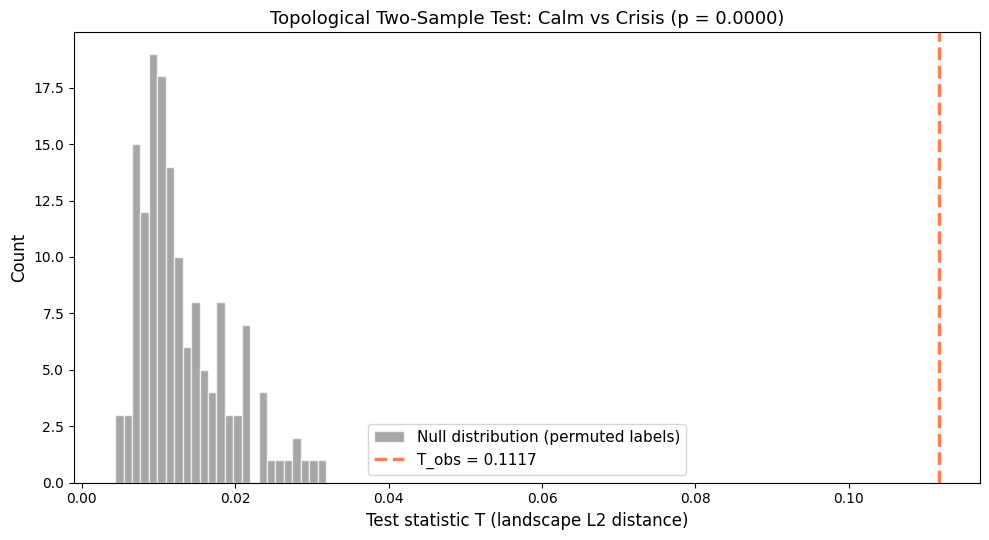


Test statistic T_obs = 0.1117
p-value = 0.0000
-> REJECT H0: Crisis and calm regimes have statistically different topology
   This supports the hypothesis that crisis dynamics create topologically
   distinct return patterns (feedback loops, herding -> higher beta_1).


In [15]:
# Run permutation test: calm vs crisis
print("Running permutation test: Calm vs Crisis regimes")
print("(This will take a few minutes due to high dimensionality...)\n")

p_val_fin, T_obs_fin, T_null_fin = landscape_permutation_test(
    X_calm, X_crisis, maxdim=1, k_max=3, n_perm=150, n_bootstrap=10, seed=42
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(T_null_fin, bins=25, color='gray', alpha=0.7, edgecolor='white',
        label='Null distribution (permuted labels)')
ax.axvline(T_obs_fin, color='coral', linewidth=2.5, linestyle='--',
           label=f'T_obs = {T_obs_fin:.4f}')
ax.set_xlabel('Test statistic T (landscape L2 distance)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Topological Two-Sample Test: Calm vs Crisis (p = {p_val_fin:.4f})', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('financial_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest statistic T_obs = {T_obs_fin:.4f}")
print(f"p-value = {p_val_fin:.4f}")
if p_val_fin < 0.05:
    print("-> REJECT H0: Crisis and calm regimes have statistically different topology")
    print("   This supports the hypothesis that crisis dynamics create topologically")
    print("   distinct return patterns (feedback loops, herding -> higher beta_1).")
else:
    print("-> FAIL TO REJECT H0")

---

## Summary

| Concept | What it gives you | Key reference |
|---------|-------------------|---------------|
| **Stability Theorem** | Persistence is Lipschitz-continuous w.r.t. input perturbations | Cohen-Steiner, Edelsbrunner, Harer (2007) |
| **Convergence** | Empirical diagrams converge to population diagram at rate $O((\log n / n)^{1/d})$ | Chazal et al. (2015) |
| **Bootstrap Confidence Sets** | Formal threshold for separating signal from noise in barcodes | Fasy, Lecci, Rinaldo, Wasserman (2014) |
| **Persistence Landscapes** | Banach-space-valued summary with CLT, mean, variance, hypothesis tests | Bubenik (2015) |
| **Persistence Images** | Stable finite-dimensional vectorization for any ML pipeline | Adams et al. (2017) |
| **Permutation Tests** | Topological two-sample test: are two datasets' shapes statistically different? | Bubenik (2015), Robinson & Turner (2017) |

### The Statistical TDA Pipeline

```
Data -> Persistence Diagram -> Vectorize (Landscape / Image) -> Statistical Inference
                |                                                      |
        Bootstrap confidence                                Permutation test
        sets (signal vs noise)                              Regression / Classification
```

### What's Next

- **Sheaf Theory** (planned) — generalizing persistence to sheaves on topological spaces, enabling local-to-global statistical reasoning.
- For a practical application of these tools to financial markets, see the [market-sentiment.io](https://market-sentiment.io) dashboard.

---

## References

1. Adams, H., Emerson, T., Kirby, M., Neville, R., Peterson, C., Shipman, P., et al. (2017). Persistence images: a stable vector representation of persistent homology. *Journal of Machine Learning Research*, 18(1), 218-252.

2. Bubenik, P. (2015). Statistical topological data analysis using persistence landscapes. *Journal of Machine Learning Research*, 16(1), 77-102.

3. Chazal, F., de Silva, V., Glisse, M., & Oudot, S. (2016). *The Structure and Stability of Persistence Modules*. Springer.

4. Chazal, F., & Michel, B. (2021). An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists. *Frontiers in Artificial Intelligence*, 4, 667963.

5. Cohen-Steiner, D., Edelsbrunner, H., & Harer, J. (2007). Stability of persistence diagrams. *Discrete & Computational Geometry*, 37(1), 103-120.

6. Fasy, B. T., Lecci, F., Rinaldo, A., Wasserman, L., Balakrishnan, S., & Singh, A. (2014). Confidence sets for persistence diagrams. *Annals of Statistics*, 42(6), 2301-2339.

7. Robinson, A., & Turner, K. (2017). Hypothesis testing for topological data analysis. *Journal of Applied and Computational Topology*, 1(2), 241-261.